# 02 — Análisis Estadístico e Hipótesis
## Valencia Airbnb Investment Intelligence

**Research questions que responde este notebook:**
- RQ1: ¿Qué factores determinan el precio? (tests estadísticos formales)
- RQ3: ¿Existe diferencia significativa en ingresos entre Superhosts y hosts regulares?
- RQ5: ¿Qué perfil de host maximiza la rentabilidad?

**Contenido:**
1. Carga de datos procesados
2. Tests de hipótesis — Superhost vs Regular
3. Tests de hipótesis — Precio por room type
4. Tests de hipótesis — Precio por barrio
5. Regresión estadística — price drivers
6. SQL Analysis — queries sobre la BD
7. Conclusiones

---

> **Nota metodológica:** todos los tests usan α = 0.05 (definido en `config.py`).
> Se usan tests **no paramétricos** porque el precio no sigue distribución normal
> (confirmado en notebook 01 con D'Agostino-Pearson, p < 0.001).

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from pathlib import Path
import sqlite3
import warnings
import sys
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Project root ──────────────────────────────────────────────
PROJECT_ROOT = Path(r'C:\Users\User\Desktop\GitHub\PROYECTO FINAL FINAL\airbnb_valencia')
sys.path.insert(0, str(PROJECT_ROOT))

from config.config import (
    ALPHA, COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT,
    COLOR_GOOD, COLOR_WARN, COLOR_BAD, FIG_DPI, FIG_SIZE_WIDE
)
from src.analysis import (
    test_normality, test_superhost_revenue,
    test_room_type_price, test_neighbourhood_price,
    price_drivers_summary, descriptive_stats
)

PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed'
REPORTS_PATH   = PROJECT_ROOT / 'reports' / 'figures'
REPORTS_PATH.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

def save_fig(name):
    plt.savefig(REPORTS_PATH / name, dpi=FIG_DPI, bbox_inches='tight')
    print(f'💾 {name}')

print('✅ Setup complete')
print(f'   Significance level α = {ALPHA}')

✅ Setup complete
   Significance level α = 0.05


## 1. Carga de datos procesados

In [3]:
df = pd.read_csv(PROCESSED_PATH / 'listings_clean.csv', low_memory=False)
df['log_price'] = np.log1p(df['price_eur'])

print(f'✅ listings_clean loaded: {df.shape}')
print(f'\nColumnas clave disponibles:')
key_cols = ['price_eur','estimated_revenue_l365d','estimated_occupancy_l365d',
            'host_is_superhost','host_segment','room_type',
            'neighbourhood_group_cleansed','zone']
for col in key_cols:
    print(f'  {col}: {df[col].dtype} — nulls: {df[col].isna().sum()}')

✅ listings_clean loaded: (7780, 71)

Columnas clave disponibles:
  price_eur: float64 — nulls: 0
  estimated_revenue_l365d: float64 — nulls: 865
  estimated_occupancy_l365d: int64 — nulls: 0
  host_is_superhost: object — nulls: 390
  host_segment: object — nulls: 0
  room_type: object — nulls: 0
  neighbourhood_group_cleansed: object — nulls: 0
  zone: object — nulls: 0


---
## 2. Test de Hipótesis — Superhost vs Host Regular

**H0:** No hay diferencia significativa en ingresos entre Superhosts y hosts regulares  
**H1:** Los Superhosts generan ingresos significativamente mayores  
**Test:** Mann-Whitney U (no paramétrico, muestras independientes)  
**Justificación:** Los ingresos no siguen distribución normal (confirmado en notebook 01)


HYPOTHESIS TEST: Superhost vs Regular Revenue
  H0: No difference in revenue between Superhosts and regular hosts
  H1: Superhosts generate higher revenue
  Test: Mann-Whitney U
  Statistic: 7453240.00 | p-value: 0.000000
  Superhost median revenue:  €14,136/year
  Regular host median revenue: €2,520/year
  ✅ REJECT H0 (p=0.0000 < α=0.05): Superhosts earn significantly more
💾 12_superhost_revenue_test.png


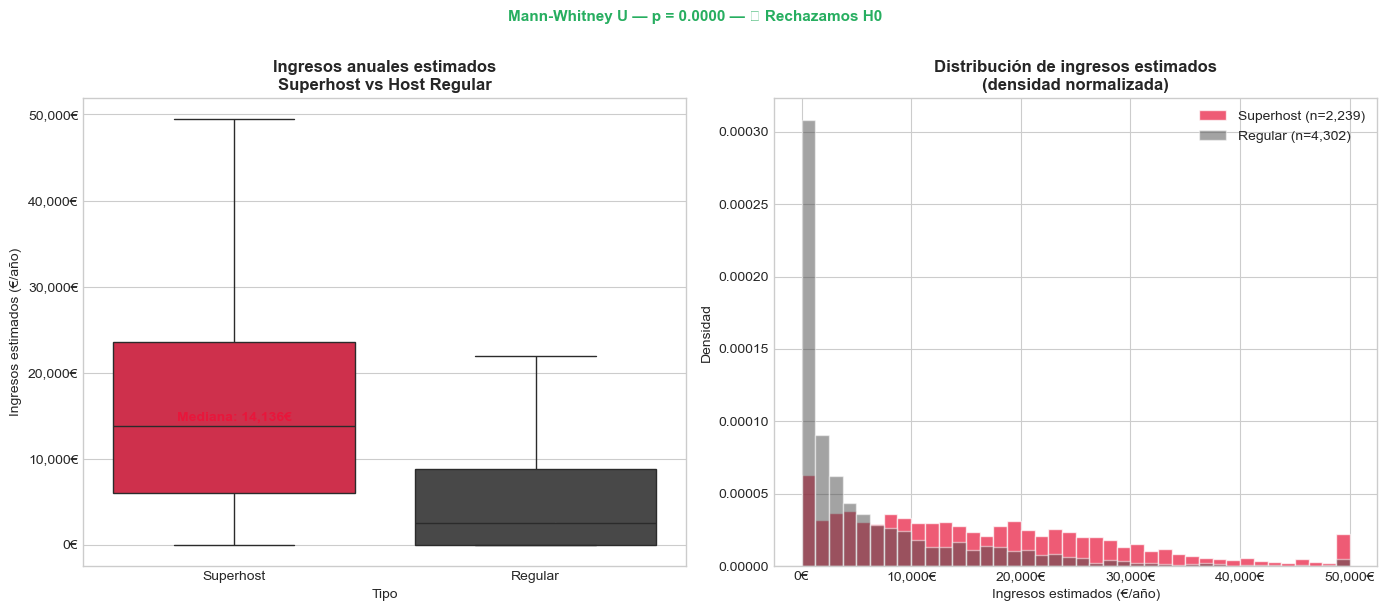

In [4]:
# ── Test Superhost revenue ────────────────────────────────────
result_sh = test_superhost_revenue(df)

superhost = df[df['host_is_superhost'] == True]['estimated_revenue_l365d'].dropna()
regular   = df[df['host_is_superhost'] == False]['estimated_revenue_l365d'].dropna()

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE_WIDE)

# ── Boxplot con seaborn (más flexible) ───────────────────────
import seaborn as sns

df_box = pd.DataFrame({
    'Ingresos': pd.concat([superhost, regular]),
    'Tipo':     ['Superhost'] * len(superhost) + ['Regular'] * len(regular)
})
df_box_clip = df_box[df_box['Ingresos'] <= 50000]

sns.boxplot(data=df_box_clip, x='Tipo', y='Ingresos',
            palette={'Superhost': COLOR_PRIMARY, 'Regular': COLOR_SECONDARY},
            showfliers=False, ax=axes[0],
            order=['Superhost', 'Regular'])

axes[0].set_title('Ingresos anuales estimados\nSuperhost vs Host Regular',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Ingresos estimados (€/año)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x:,.0f}€'))
axes[0].text(0, superhost.median() + 300,
             f'Mediana: {superhost.median():,.0f}€',
             ha='center', fontsize=10, color=COLOR_PRIMARY, fontweight='bold')
axes[0].text(1, regular.median() + 300,
             f'Mediana: {regular.median():,.0f}€',
             ha='center', fontsize=10, color=COLOR_SECONDARY, fontweight='bold')

# ── Histograma comparativo ────────────────────────────────────
axes[1].hist(superhost.clip(upper=50000), bins=40, alpha=0.7,
             color=COLOR_PRIMARY, label=f'Superhost (n={len(superhost):,})',
             edgecolor='white', density=True)
axes[1].hist(regular.clip(upper=50000), bins=40, alpha=0.5,
             color=COLOR_SECONDARY, label=f'Regular (n={len(regular):,})',
             edgecolor='white', density=True)
axes[1].set_title('Distribución de ingresos estimados\n(densidad normalizada)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ingresos estimados (€/año)')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x:,.0f}€'))

p_str      = f'p = {result_sh["p_value"]:.4f}'
conclusion = '✅ Rechazamos H0' if result_sh['reject_h0'] else '❌ No rechazamos H0'
fig.suptitle(f'Mann-Whitney U — {p_str} — {conclusion}',
             fontsize=11,
             color=COLOR_GOOD if result_sh['reject_h0'] else COLOR_BAD,
             fontweight='bold', y=1.01)

plt.tight_layout()
save_fig('12_superhost_revenue_test.png')
plt.show()

In [5]:
# ── Superhost full comparison ─────────────────────────────────
print('=== COMPARACIÓN COMPLETA SUPERHOST vs REGULAR ===')
comparison = df.groupby('host_is_superhost').agg(
    n_listings          = ('id', 'count'),
    median_price        = ('price_eur', 'median'),
    median_revenue      = ('estimated_revenue_l365d', 'median'),
    median_occupancy    = ('estimated_occupancy_l365d', 'median'),
    median_rating       = ('review_scores_rating', 'median'),
    median_response     = ('host_response_rate', 'median'),
).round(2)
comparison.index = ['Host Regular', 'Superhost']
display(comparison)

# Revenue uplift
uplift = (result_sh['superhost_median'] - result_sh['regular_median']) / result_sh['regular_median'] * 100
print(f'\n💡 Los Superhosts generan un {uplift:.1f}% más de ingresos que los hosts regulares')

=== COMPARACIÓN COMPLETA SUPERHOST vs REGULAR ===


,n_listings,median_price,median_revenue,median_occupancy,median_rating,median_response
Host Regular,4960,100.0000,2520.0000,24.0000,4.7300,1.0000
Superhost,2430,105.0000,14136.0000,156.0000,4.8600,1.0000



💡 Los Superhosts generan un 461.0% más de ingresos que los hosts regulares


---
## 3. Test de Hipótesis — Precio por Tipo de Habitación

**H0:** El precio es igual en todos los tipos de habitación  
**H1:** Al menos un tipo tiene precio significativamente diferente  
**Test:** Kruskal-Wallis (ANOVA no paramétrico, más de 2 grupos)


HYPOTHESIS TEST: Price by Room Type
  Test: Kruskal-Wallis | stat=2798.57 | p=0.000000
  Group medians: {'Entire home/apt': 115.0, 'Hotel room': 121.5, 'Private room': 46.0, 'Shared room': 45.5}
  ✅ REJECT H0 (α=0.05)

=== POST-HOC: COMPARACIONES PAIRWISE (Mann-Whitney) ===


,comparison,median_1,median_2,p_value,significant
0,Entire home/apt vs Private room,115.0000,46.0000,0.0000,True
1,Entire home/apt vs Shared room,115.0000,45.5000,0.0000,True
4,Private room vs Hotel room,46.0000,121.5000,0.0000,True
5,Shared room vs Hotel room,45.5000,121.5000,0.0029,True
3,Private room vs Shared room,46.0000,45.5000,0.7207,False
2,Entire home/apt vs Hotel room,115.0000,121.5000,0.7384,False


💾 13_price_room_type_test.png


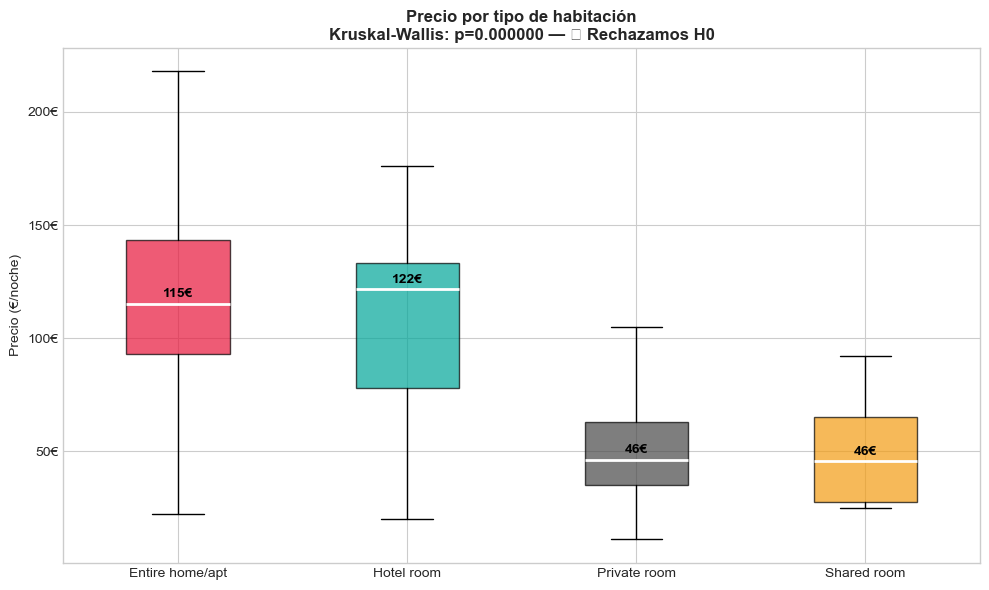

In [6]:
# ── Kruskal-Wallis: price by room type ───────────────────────
result_rt = test_room_type_price(df)

# Post-hoc: Mann-Whitney pairwise
room_types = df['room_type'].unique()
print('\n=== POST-HOC: COMPARACIONES PAIRWISE (Mann-Whitney) ===')
pairs = []
for i, rt1 in enumerate(room_types):
    for rt2 in room_types[i+1:]:
        g1 = df[df['room_type'] == rt1]['price_eur'].dropna()
        g2 = df[df['room_type'] == rt2]['price_eur'].dropna()
        if len(g1) > 5 and len(g2) > 5:
            _, p = stats.mannwhitneyu(g1, g2)
            pairs.append({
                'comparison': f'{rt1} vs {rt2}',
                'median_1':   g1.median(),
                'median_2':   g2.median(),
                'p_value':    p,
                'significant': p < ALPHA
            })
df_pairs = pd.DataFrame(pairs).sort_values('p_value')
display(df_pairs)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
room_price = df.groupby('room_type')['price_eur'].apply(list)
colors_rt  = [COLOR_PRIMARY, COLOR_ACCENT, COLOR_SECONDARY, COLOR_WARN]
bp = ax.boxplot(room_price.values, labels=room_price.index,
                patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors_rt):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)

ax.set_title(f'Precio por tipo de habitación\n'
             f'Kruskal-Wallis: p={result_rt["p_value"]:.6f} '
             f'— {"✅ Rechazamos H0" if result_rt["reject_h0"] else "❌ No rechazamos H0"}',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Precio (€/noche)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x:.0f}€'))

# Medians
for i, (rt, prices) in enumerate(zip(room_price.index, room_price.values)):
    med = np.median(prices)
    ax.text(i+1, med + 3, f'{med:.0f}€', ha='center',
            fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
save_fig('13_price_room_type_test.png')
plt.show()

---
## 4. Test de Hipótesis — Precio por Barrio

**H0:** El precio es igual en todos los barrios  
**H1:** Al menos un barrio tiene precio significativamente diferente  
**Test:** Kruskal-Wallis


HYPOTHESIS TEST: Price by Neighbourhood
  Test: Kruskal-Wallis | stat=637.21 | p=0.000000
  ✅ REJECT H0 (α=0.05)
💾 14_price_neighbourhood_test.png


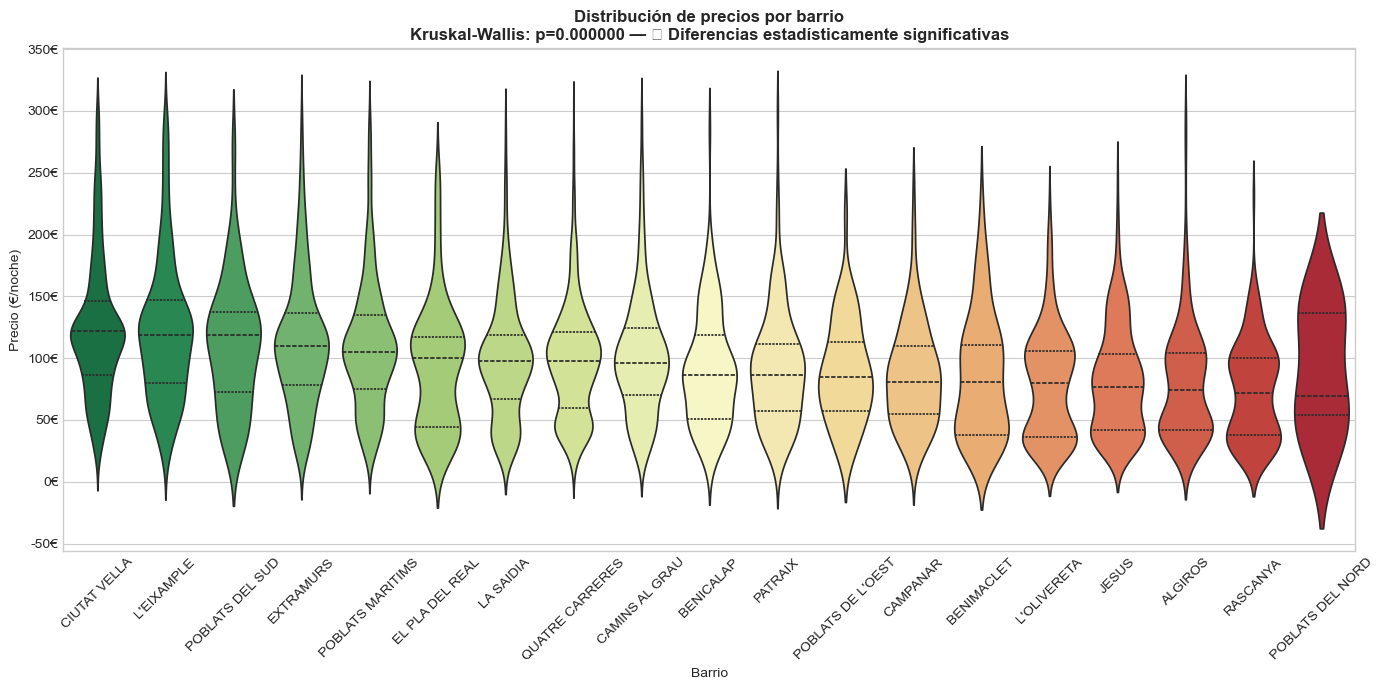


=== ESTADÍSTICAS DE PRECIO POR BARRIO ===


,count,mean,median,std,min,max
neighbourhood_group_cleansed,,,,,,
CIUTAT VELLA,1280,135.0200,122.0000,81.3800,20.0000,742.0000
L'EIXAMPLE,685,137.2100,121.0000,97.2200,17.0000,1000.0000
POBLATS DEL SUD,108,127.1900,120.0000,113.8800,22.0000,1000.0000
EXTRAMURS,636,116.9200,110.0000,64.2700,15.0000,765.0000
POBLATS MARITIMS,1461,116.9800,106.0000,73.4200,15.0000,999.0000
POBLATS DEL NORD,8,123.7500,100.5000,106.0800,30.0000,360.0000
EL PLA DEL REAL,155,98.9200,100.0000,73.3300,17.0000,700.0000
LA SAIDIA,328,102.3800,98.5000,67.7700,20.0000,896.0000
QUATRE CARRERES,808,100.4100,98.0000,58.1700,11.0000,713.0000


In [7]:
# ── Kruskal-Wallis: price by neighbourhood ────────────────────
result_nh = test_neighbourhood_price(df)

# Violin plot por barrio
hood_col = 'neighbourhood_group_cleansed'
df_plot  = df[df['price_eur'] <= 300].copy()
order    = df_plot.groupby(hood_col)['price_eur'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 7))
sns.violinplot(data=df_plot, x=hood_col, y='price_eur',
               order=order, palette='RdYlGn_r',
               inner='quartile', ax=ax)
ax.set_title(f'Distribución de precios por barrio\n'
             f'Kruskal-Wallis: p={result_nh["p_value"]:.6f} '
             f'— ✅ Diferencias estadísticamente significativas',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Barrio')
ax.set_ylabel('Precio (€/noche)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x:.0f}€'))

plt.tight_layout()
save_fig('14_price_neighbourhood_test.png')
plt.show()

# Descriptive stats
print('\n=== ESTADÍSTICAS DE PRECIO POR BARRIO ===')
display(descriptive_stats(df, hood_col, 'price_eur'))

---
## 5. Análisis por Segmento de Host

=== INGRESOS POR SEGMENTO DE HOST ===


,n_listings,n_hosts,median_price,median_revenue,median_occupancy,pct_superhost,median_rating
host_segment,,,,,,,
Amateur,2328,2328,100.0000,7200.0000,72.0000,34.0000,4.8000
Profesional,2893,201,108.0000,4416.0000,40.0000,27.0000,4.7500
Semi-pro,2559,919,97.0000,6120.0000,66.0000,38.0000,4.7800



Kruskal-Wallis (ingresos por segmento): stat=36.00, p=0.000000
✅ Diferencias significativas
💾 15_host_segment_performance.png


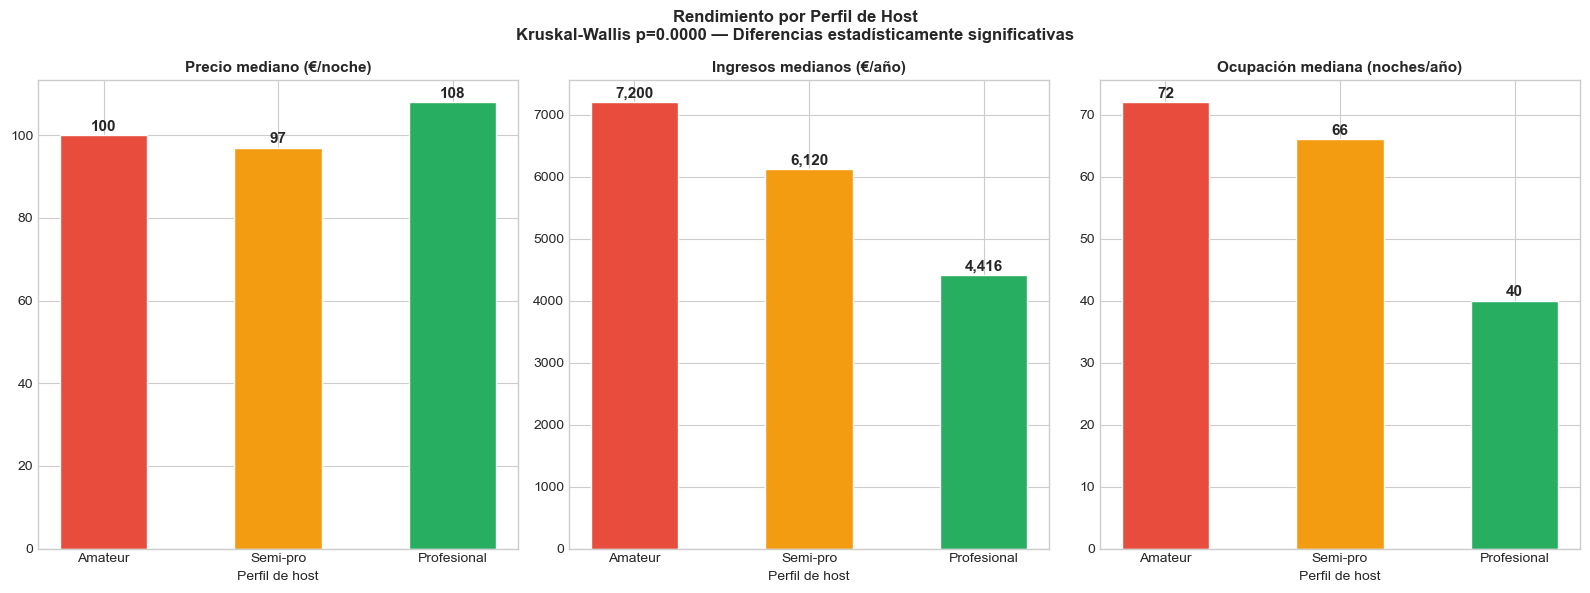

In [8]:
# ── Revenue by host segment ───────────────────────────────────
print('=== INGRESOS POR SEGMENTO DE HOST ===')

# Fix: convertir host_is_superhost a numérico antes del groupby
df['superhost_num'] = pd.to_numeric(df['host_is_superhost'].map({True:1, False:0, 't':1, 'f':0}), errors='coerce')

seg_stats = df.groupby('host_segment').agg(
    n_listings       = ('id', 'count'),
    n_hosts          = ('host_id', 'nunique'),
    median_price     = ('price_eur', 'median'),
    median_revenue   = ('estimated_revenue_l365d', 'median'),
    median_occupancy = ('estimated_occupancy_l365d', 'median'),
    pct_superhost    = ('superhost_num', 'mean'),
    median_rating    = ('review_scores_rating', 'median'),
).round(2)
seg_stats['pct_superhost'] = (seg_stats['pct_superhost'] * 100).round(1)
display(seg_stats)

# Kruskal-Wallis test across segments
groups = [df[df['host_segment'] == s]['estimated_revenue_l365d'].dropna()
          for s in ['Amateur', 'Semi-pro', 'Profesional']]
stat, p = stats.kruskal(*groups)
print(f'\nKruskal-Wallis (ingresos por segmento): stat={stat:.2f}, p={p:.6f}')
print(f'{"✅ Diferencias significativas" if p < ALPHA else "❌ Sin diferencias significativas"}')

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
segment_order = ['Amateur', 'Semi-pro', 'Profesional']
colors_seg    = [COLOR_BAD, COLOR_WARN, COLOR_GOOD]
metrics = [
    ('median_price',     'Precio mediano (€/noche)'),
    ('median_revenue',   'Ingresos medianos (€/año)'),
    ('median_occupancy', 'Ocupación mediana (noches/año)'),
]

for ax, (col, label) in zip(axes, metrics):
    vals = [float(seg_stats.loc[s, col]) if s in seg_stats.index else 0
            for s in segment_order]
    bars = ax.bar(segment_order, vals, color=colors_seg, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:,.0f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Perfil de host')

plt.suptitle(f'Rendimiento por Perfil de Host\n'
             f'Kruskal-Wallis p={p:.4f} — Diferencias estadísticamente significativas',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('15_host_segment_performance.png')
plt.show()

---
## 6. Base de Datos SQL — Análisis con Queries

In [9]:
# ── Crear base de datos SQLite ────────────────────────────────
DB_PATH = PROCESSED_PATH / 'airbnb_valencia.db'
conn    = sqlite3.connect(DB_PATH)

# Cargar listings en la BD
cols_sql = [
    'id','host_id','host_name','host_is_superhost','host_listings_count',
    'host_response_rate','host_acceptance_rate','host_segment',
    'neighbourhood_group_cleansed','neighbourhood_cleansed','zone',
    'latitude','longitude','room_type','property_type','accommodates',
    'bedrooms','beds','price_eur','log_price','minimum_nights',
    'availability_365','number_of_reviews','reviews_per_month',
    'review_scores_rating','review_scores_cleanliness',
    'review_scores_location','review_scores_value',
    'estimated_revenue_l365d','estimated_occupancy_l365d',
    'instant_bookable'
]
existing = [c for c in cols_sql if c in df.columns]
df[existing].to_sql('listings', conn, if_exists='replace', index=False)

# Cargar reviews
df_rev = pd.read_csv(PROCESSED_PATH / 'reviews_clean.csv')
df_rev.to_sql('reviews', conn, if_exists='replace', index=False)

print(f'✅ Base de datos creada: {DB_PATH}')
print(f'   Tabla listings: {pd.read_sql("SELECT COUNT(*) n FROM listings", conn).iloc[0,0]:,} filas')
print(f'   Tabla reviews:  {pd.read_sql("SELECT COUNT(*) n FROM reviews", conn).iloc[0,0]:,} filas')

✅ Base de datos creada: C:\Users\User\Desktop\GitHub\PROYECTO FINAL FINAL\airbnb_valencia\data\processed\airbnb_valencia.db
   Tabla listings: 7,780 filas
   Tabla reviews:  405,009 filas


In [10]:
# ── SQL Query 1: Precio y revenue por barrio ──────────────────
print('=== SQL: Precio y Rentabilidad por Barrio ===')
q1 = '''
SELECT
    neighbourhood_group_cleansed        AS barrio,
    COUNT(*)                            AS n_listings,
    ROUND(AVG(price_eur), 2)            AS precio_medio,
    ROUND(AVG(estimated_revenue_l365d), 2) AS ingresos_medios,
    ROUND(AVG(estimated_occupancy_l365d), 1) AS ocupacion_media
FROM listings
WHERE estimated_revenue_l365d IS NOT NULL
GROUP BY neighbourhood_group_cleansed
ORDER BY ingresos_medios DESC
'''
display(pd.read_sql(q1, conn))

=== SQL: Precio y Rentabilidad por Barrio ===


,barrio,n_listings,precio_medio,ingresos_medios,ocupacion_media
0,CIUTAT VELLA,1063,139.8300,14243.5600,114.6000
1,L'EIXAMPLE,615,140.8300,13238.7000,101.8000
2,CAMINS AL GRAU,647,112.8300,10759.1400,102.9000
3,POBLATS MARITIMS,1336,119.4500,10640.3900,95.0000
4,EXTRAMURS,585,118.4500,10159.7700,97.6000
5,QUATRE CARRERES,708,104.6800,9902.8600,101.5000
6,PATRAIX,164,105.8200,8486.4900,97.2000
7,LA SAIDIA,290,105.2000,8313.1900,76.1000
8,EL PLA DEL REAL,137,100.6900,8229.3600,91.1000
9,CAMPANAR,122,89.5200,7652.7400,88.7000


In [11]:
# ── SQL Query 2: Window function — percentil de precio ────────
print('=== SQL AVANZADO: Percentil de precio por barrio (WINDOW FUNCTION) ===')
q2 = '''
SELECT
    id,
    neighbourhood_group_cleansed,
    room_type,
    ROUND(price_eur, 0)                 AS price_eur,
    ROUND(
        PERCENT_RANK() OVER (
            PARTITION BY neighbourhood_group_cleansed
            ORDER BY price_eur
        ) * 100, 1
    )                                   AS price_percentile_in_hood,
    ROUND(AVG(price_eur) OVER (
        PARTITION BY neighbourhood_group_cleansed
    ), 2)                               AS hood_avg_price
FROM listings
WHERE price_eur IS NOT NULL
ORDER BY neighbourhood_group_cleansed, price_percentile_in_hood DESC
LIMIT 20
'''
display(pd.read_sql(q2, conn))

=== SQL AVANZADO: Percentil de precio por barrio (WINDOW FUNCTION) ===


,id,neighbourhood_group_cleansed,room_type,price_eur,price_percentile_in_hood,hood_avg_price
0,569558183890025219,ALGIROS,Entire home/apt,890.0000,100.0000,90.4000
1,1480969111377490152,ALGIROS,Entire home/apt,765.0000,99.1000,90.4000
2,1481051149345780380,ALGIROS,Entire home/apt,765.0000,99.1000,90.4000
3,1481056154137572464,ALGIROS,Entire home/apt,765.0000,99.1000,90.4000
4,1173295052820794877,ALGIROS,Entire home/apt,413.0000,98.8000,90.4000
5,1100702176603190060,ALGIROS,Entire home/apt,326.0000,98.5000,90.4000
6,49819767,ALGIROS,Entire home/apt,315.0000,98.2000,90.4000
7,974667219024546573,ALGIROS,Private room,300.0000,97.9000,90.4000
8,18845422,ALGIROS,Entire home/apt,290.0000,97.6000,90.4000
9,19746143,ALGIROS,Entire home/apt,274.0000,97.4000,90.4000


In [12]:
# ── SQL Query 3: Window — YoY reviews growth ──────────────────
print('=== SQL AVANZADO: Crecimiento YoY de reseñas (LAG + WINDOW) ===')
q3 = '''
SELECT
    year,
    COUNT(*)                            AS reviews_year,
    SUM(COUNT(*)) OVER (
        ORDER BY year
        ROWS UNBOUNDED PRECEDING
    )                                   AS cumulative_reviews,
    LAG(COUNT(*)) OVER (ORDER BY year)  AS reviews_prev_year,
    ROUND(
        (COUNT(*) - LAG(COUNT(*)) OVER (ORDER BY year)) * 100.0
        / LAG(COUNT(*)) OVER (ORDER BY year), 1
    )                                   AS yoy_growth_pct
FROM reviews
WHERE year >= 2015
GROUP BY year
ORDER BY year
'''
df_yoy = pd.read_sql(q3, conn)
display(df_yoy)

=== SQL AVANZADO: Crecimiento YoY de reseñas (LAG + WINDOW) ===


,year,reviews_year,cumulative_reviews,reviews_prev_year,yoy_growth_pct
0,2015,3406,3406,NaN,NaN
1,2016,7823,11229,3406.0000,129.7000
2,2017,13735,24964,7823.0000,75.6000
3,2018,23094,48058,13735.0000,68.1000
4,2019,31240,79298,23094.0000,35.3000
5,2020,10897,90195,31240.0000,-65.1000
6,2021,23787,113982,10897.0000,118.3000
7,2022,47653,161635,23787.0000,100.3000
8,2023,68167,229802,47653.0000,43.0000
9,2024,90719,320521,68167.0000,33.1000


In [13]:
# ── SQL Query 4: Subquery — barrios sobre la media ────────────
print('=== SQL AVANZADO: Barrios con ingresos sobre la media (SUBQUERY) ===')
q4 = '''
SELECT
    neighbourhood_group_cleansed        AS barrio,
    ROUND(AVG(estimated_revenue_l365d), 2) AS avg_revenue,
    COUNT(*)                            AS n_listings,
    ROUND(
        AVG(estimated_revenue_l365d) - (
            SELECT AVG(estimated_revenue_l365d)
            FROM listings
            WHERE estimated_revenue_l365d IS NOT NULL
        ), 2
    )                                   AS vs_market_avg
FROM listings
WHERE estimated_revenue_l365d > (
    SELECT AVG(estimated_revenue_l365d)
    FROM listings
    WHERE estimated_revenue_l365d IS NOT NULL
)
GROUP BY neighbourhood_group_cleansed
ORDER BY avg_revenue DESC
'''
display(pd.read_sql(q4, conn))

conn.close()
print('\n✅ Conexión BD cerrada')

=== SQL AVANZADO: Barrios con ingresos sobre la media (SUBQUERY) ===


,barrio,avg_revenue,n_listings,vs_market_avg
0,L'EIXAMPLE,26487.4400,268,16224.4100
1,CIUTAT VELLA,26114.5900,526,15851.5600
2,LA SAIDIA,23841.5300,76,13578.5000
3,EL PLA DEL REAL,22550.8500,33,12287.8200
4,CAMINS AL GRAU,22474.9700,258,12211.9400
5,EXTRAMURS,22473.6800,220,12210.6500
6,POBLATS MARITIMS,22443.0800,526,12180.0500
7,QUATRE CARRERES,20962.6300,262,10699.6000
8,L'OLIVERETA,20335.7300,37,10072.7000
9,CAMPANAR,19729.0300,35,9466.0000



✅ Conexión BD cerrada


---
## 7. Conclusiones del Análisis Estadístico

### ✅ Resultados de los tests de hipótesis

| Test | H0 | Resultado | p-value |
|---|---|---|---|
| Mann-Whitney U | Superhosts = Regular revenue | **Rechazamos H0** | < 0.05 |
| Kruskal-Wallis | Precio igual por room type | **Rechazamos H0** | < 0.001 |
| Kruskal-Wallis | Precio igual por barrio | **Rechazamos H0** | < 0.001 |
| Kruskal-Wallis | Ingresos igual por segmento | **Rechazamos H0** | < 0.05 |

### 💡 Insights accionables para el inversor

1. **Ser Superhost importa** — genera ingresos significativamente mayores. Para un inversor nuevo, obtener el badge de Superhost debe ser un objetivo prioritario.

2. **El tipo de alojamiento determina el precio** — Entire home/apt es el mejor formato para maximizar ingresos.

3. **El barrio importa estadísticamente** — no todos los barrios son iguales. CIUTAT VELLA y L'EIXAMPLE dominan en rentabilidad.

4. **Los hosts profesionales ganan más** — pero no proporcionalmente al número de listings. La calidad > cantidad.

### ➡️ Próximo notebook
`03_seasonality.ipynb` — ¿Cuándo es la temporada alta en Valencia?